# Machine Learning Pipeline

Now that we have experience preparing data for input to machine learning libraries, the next step will be to train, tune, and test a model.  You will perform all three of these steps in this hands-on activity.

The assignment consists of the following steps:

1. Load two datasets and prepare their representations and labels for model input. 
2. Split the data into training and testing.
3. Select a model, and identify the parameters to tune.
4. Tune the model.
5. Evaluate the model's performance.

In [2]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Convert the Packet Capture Into Flows

1. Load the two packet captures for HTTP requests and Log4j scan, 
2. convert them into traffic flows, 
3. generate features from the flow,  
4. label the traffic,
5. normalize your labeled features into a 2D matrix

In [3]:
import numpy as np

# The 12 STATS features netml computes for every flow, in order.
STATS_COLUMNS = [
    "duration", "pkts_rate", "bytes_rate",
    "size_mean", "size_std", "size_q1", "size_q2", "size_q3",
    "size_min", "size_max", "num_pkts", "num_bytes",
]

def pcap_to_features(path, feat_type="STATS", flow_ptks_thres=2):
    """Read a pcap, group packets into flows, and summarize each flow as a feature vector."""
    pcap = PCAP(path, flow_ptks_thres=flow_ptks_thres)
    pcap.pcap2flows()
    pcap.flow2features(feat_type, fft=False, header=False)
    return pcap

http = pcap_to_features("data/http.pcap")     # benign web traffic
log4j = pcap_to_features("data/log4j.pcap")   # Log4Shell scan

print(f"http.pcap : {len(http.flows):5d} flows -> features {http.features.shape}")
print(f"log4j.pcap: {len(log4j.flows):5d} flows -> features {log4j.features.shape}")


http.pcap :   291 flows -> features (291, 12)
log4j.pcap:  4795 flows -> features (4795, 12)


In [4]:
# Label: benign HTTP = 0, log4j scan = 1.
# Convention: the "positive" class is the event we want to DETECT, so that
# recall reads as "what fraction of attacks did we catch?"
X = np.vstack([http.features, log4j.features])
y = np.concatenate([
    np.zeros(len(http.features), dtype=int),
    np.ones(len(log4j.features), dtype=int),
])

print(f"X: {X.shape}   y: {y.shape}")
print(f"benign (0): {(y == 0).sum():5d}")
print(f"attack (1): {(y == 1).sum():5d}   -> {y.mean():.1%} of the data")

# The bar to beat: a model that ignores X and always guesses the majority class.
print(f"\nmajority-class baseline accuracy: {max(y.mean(), 1 - y.mean()):.1%}")


X: (5086, 12)   y: (5086,)
benign (0):   291
attack (1):  4795   -> 94.3% of the data

majority-class baseline accuracy: 94.3%


## Evaluating a Machine Learning Model

The goal of supervised learning is to train a model that takes examples and predicts labels for these examples that are as close as possible to the actual labels. For instance, in this example above, a model might take features from a traffic trace and predict whether the traffic constitutes regular web traffic or a scan.

How do you measure whether the model is succeeding if you don't know the true labels for new observations? The way to solve this problem is to test the performance of the trained algorithm on additional data that it has never seen, but for which you already know the correct labels. 

This requires that you train the algorithm using only a portion of the entire labeled dataset (the **training set**) and withold the rest of the labeled data (the **test set**) for testing how well the model generalizes to new information. 

To evaluate the model, we will need to split the data into train and test sets.

### Split into Training and Test Sets

Split your data into a training and test set using scikit-learn. A common split is to train on 80% of your data, while withholding 20% of the data. 

In [5]:
from sklearn.model_selection import train_test_split

# Why stratify? Only 291 of 5086 flows are benign. Left to chance, the number of
# benign flows landing in the test set swings a lot from one random seed to the next.
print("benign flows in a 20% test set, across 8 random seeds:")
for seed in range(8):
    _, _, _, y_te_plain = train_test_split(X, y, test_size=0.2, random_state=seed)
    _, _, _, y_te_strat = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    print(f"  seed {seed}:  unstratified {(y_te_plain == 0).sum():3d}"
          f"   stratified {(y_te_strat == 0).sum():3d}")

# The split we'll actually use. stratify=y keeps the class ratio identical in both halves.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\ntrain: {X_train.shape}   {(y_train == 1).mean():.1%} attack")
print(f"test:  {X_test.shape}   {(y_test == 1).mean():.1%} attack")


benign flows in a 20% test set, across 8 random seeds:
  seed 0:  unstratified  58   stratified  58
  seed 1:  unstratified  65   stratified  58
  seed 2:  unstratified  65   stratified  58
  seed 3:  unstratified  54   stratified  58
  seed 4:  unstratified  57   stratified  58
  seed 5:  unstratified  58   stratified  58
  seed 6:  unstratified  60   stratified  58
  seed 7:  unstratified  53   stratified  58

train: (4068, 12)   94.3% attack
test:  (1018, 12)   94.3% attack


### Training Your Model

Now that you have split your data into training and testing sets, you are ready to train and evaluate a model. 

Import a machine learning model of your choice, use your training set to train the model, and use the test set to evaluate it. 

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

# The "do nothing" baseline, made concrete: ignore X entirely, always guess
# the majority class. Any real model has to beat this to have earned anything.
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"baseline accuracy: {dummy.score(X_test, y_test):.4f}")

# A real model. n_estimators / max_depth are HYPERPARAMETERS (we choose them up front);
# the split thresholds inside each tree are PARAMETERS (fit() learns them from data).
# No scaler: trees split on thresholds, so they're invariant to feature scale.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"forest   accuracy: {rf.score(X_test, y_test):.4f}")

# Which of the 12 STATS features is the forest actually leaning on?
importances = pd.Series(rf.feature_importances_, index=STATS_COLUMNS)
print("\ntop features:")
print(importances.sort_values(ascending=False).head(12).to_string(float_format="%.3f"))


baseline accuracy: 0.9430
forest   accuracy: 0.9941

top features:
size_max     0.159
num_bytes    0.132
size_q2      0.108
num_pkts     0.104
bytes_rate   0.092
size_q3      0.079
duration     0.069
size_std     0.066
size_min     0.064
pkts_rate    0.058
size_mean    0.038
size_q1      0.030


### Test Your Trained Model

You can now evaluate how well your trained model works.  There are several valuable ways to visualize your results. You might use techniques such as a confusion matrix, or a receiver operating characteristic (ROC) curve. Below we will gain some experience plotting both of those.  This [documentation](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_display_object_visualization.html) may help you with plotting these results.

#### Confusion Matrix 

A confusion matrix is a one way to understand errors of different types. We can see a lot of examples off diagonal, suggesting a fair number of incorrect answers.

TN (benign, called benign):   52    FP (benign, cried wolf):      6
FN (attack, MISSED):           0    TP (attack, caught):        960


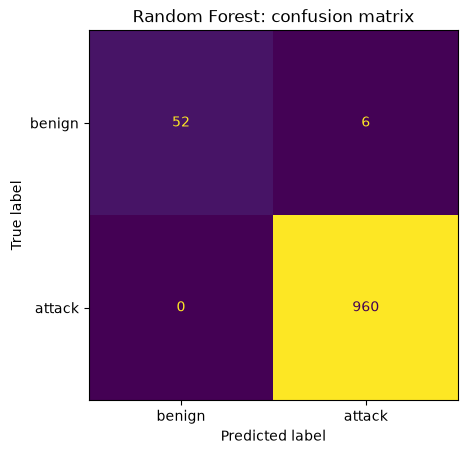

              precision    recall  f1-score   support

      benign     1.0000    0.8966    0.9455        58
      attack     0.9938    1.0000    0.9969       960

    accuracy                         0.9941      1018
   macro avg     0.9969    0.9483    0.9712      1018
weighted avg     0.9941    0.9941    0.9940      1018



In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN (benign, called benign): {tn:4d}    FP (benign, cried wolf):   {fp:4d}")
print(f"FN (attack, MISSED):        {fn:4d}    TP (attack, caught):       {tp:4d}")

ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, display_labels=["benign", "attack"], colorbar=False
)
plt.title("Random Forest: confusion matrix")
plt.show()

# Accuracy is one number averaged over 1018 rows, 94% of which are attacks.
# Per-class precision/recall shows how we do on the 58 benign flows specifically.
print(classification_report(y_test, y_pred, target_names=["benign", "attack"], digits=4))


#### Receiver Operating Characteristic

Some models can output different classes based on a threshold that is set for the decision. 

first 10 test flows:
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)
  score 0.00 -> predicted 0   (actual 0)
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)
  score 1.00 -> predicted 1   (actual 1)


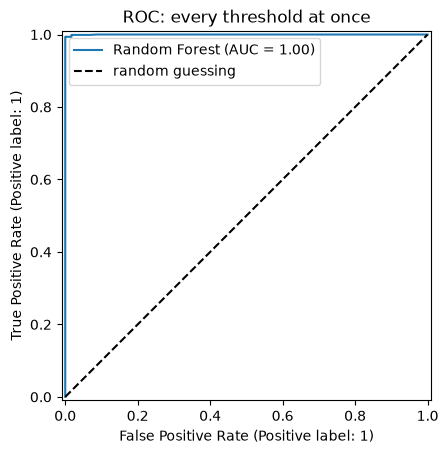

In [8]:
from sklearn.metrics import RocCurveDisplay

# predict() is really predict_proba() >= 0.5. The score is the fraction of the
# 100 trees that voted "attack" -- the threshold 0.5 is just a default, not a law.
y_score = rf.predict_proba(X_test)[:, 1]   # column 1 = P(attack)

print("first 10 test flows:")
for score, truth in list(zip(y_score, y_test))[:10]:
    print(f"  score {score:.2f} -> predicted {int(score >= 0.5)}   (actual {truth})")

RocCurveDisplay.from_predictions(y_test, y_score, name="Random Forest")
plt.plot([0, 1], [0, 1], "k--", label="random guessing")
plt.title("ROC: every threshold at once")
plt.legend()
plt.show()


#### Area Under the Curve (AUC)

From the ROC above, you can also compute a metric called the area under the curve (AUC). Visually, this is the area under the curve that you just plotted. You could see, intuitively, that the "best" performance should yield an AUC of 1, and the worst performance would yield an AUC closer to 0.5.

Scikit learn also has a function for computing AUC.  Compute the area under the curve.

ROC AUC:                0.9998   (0.5 = random guessing)
Average Precision (AP): 1.0000   (baseline = 0.9430, the attack rate)


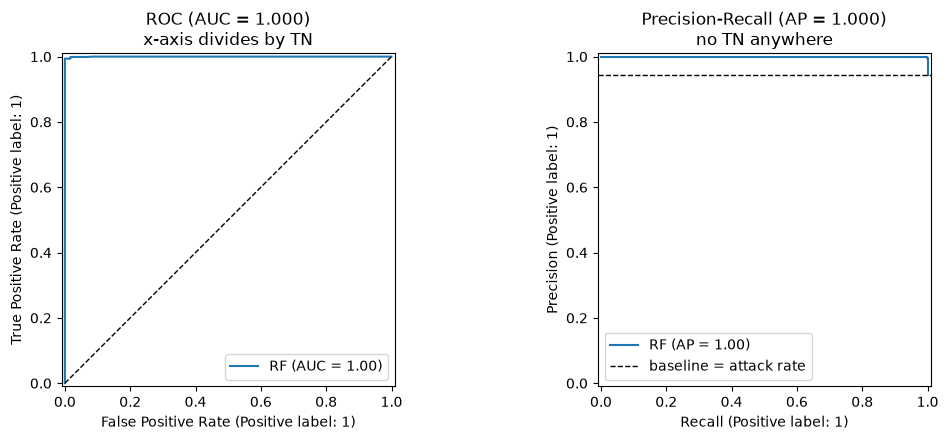

In [12]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, roc_auc_score

auc = roc_auc_score(y_test, y_score)
ap = average_precision_score(y_test, y_score)

print(f"ROC AUC:                {auc:.4f}   (0.5 = random guessing)")
print(f"Average Precision (AP): {ap:.4f}   (baseline = {y_test.mean():.4f}, the attack rate)")

# The two curves side by side. Same model, same scores -- different denominators.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[0], name="RF")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title(f"ROC (AUC = {auc:.3f})\nx-axis divides by TN")

PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[1], name="RF")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="baseline = attack rate")
axes[1].set_title(f"Precision-Recall (AP = {ap:.3f})\nno TN anywhere")
axes[1].legend()

plt.tight_layout()
plt.show()


                         attack = positive   benign = positive
class prevalence                    0.9430              0.0570
ROC AUC                             0.9998              0.9998
Average Precision                   1.0000              0.9972
AP baseline                         0.9430              0.0570


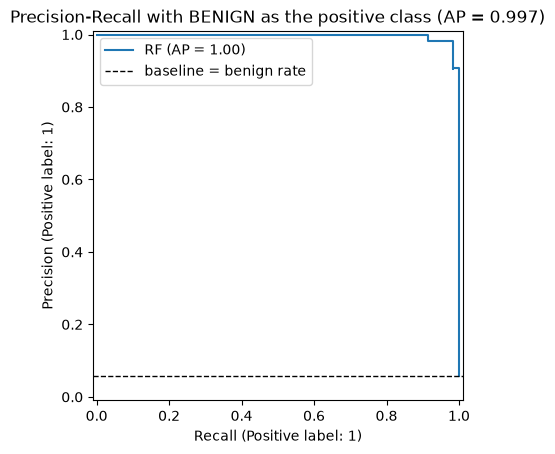

In [11]:
# AP = 1.0 came from pointing PR at the ABUNDANT class. Point it at the rare one:
# treat BENIGN as positive (only 5.7% of the test set) and recompute.
y_test_benign = 1 - y_test                  # benign becomes the positive label
y_score_benign = rf.predict_proba(X_test)[:, 0]   # P(benign)

auc_b = roc_auc_score(y_test_benign, y_score_benign)
ap_b = average_precision_score(y_test_benign, y_score_benign)

print(f"{'':22}{'attack = positive':>20}{'benign = positive':>20}")
print(f"{'class prevalence':22}{y_test.mean():>20.4f}{y_test_benign.mean():>20.4f}")
print(f"{'ROC AUC':22}{auc:>20.4f}{auc_b:>20.4f}")
print(f"{'Average Precision':22}{ap:>20.4f}{ap_b:>20.4f}")
print(f"{'AP baseline':22}{y_test.mean():>20.4f}{y_test_benign.mean():>20.4f}")

PrecisionRecallDisplay.from_predictions(y_test_benign, y_score_benign, name="RF")
plt.axhline(y_test_benign.mean(), color="k", ls="--", lw=1, label="baseline = benign rate")
plt.title(f"Precision-Recall with BENIGN as the positive class (AP = {ap_b:.3f})")
plt.legend()
plt.show()


In [ ]:
# The threshold is a dial, and 0.5 is just the factory setting.
# Try several dial positions and see what each one costs.
print(f"{'dial':>6}{'false alarms':>14}{'missed scans':>14}")
for t in [0.10, 0.25, 0.40, 0.50, 0.60, 0.75, 0.90]:
    pred_t = (y_score >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t).ravel()
    marker = "  <- current" if t == 0.50 else ""
    print(f"{t:>6.2f}{fp_t:>14d}{fn_t:>14d}{marker}")

print("\nDial UP  -> guard is more reluctant: fewer false alarms, more misses.")
print("Dial DOWN-> guard is more paranoid:  more false alarms, fewer misses.")
print("No row is 'best'. The right row is the one whose tradeoff matches your costs.")


## Thought Question

Which evaluation model is more appropriate, and when (i.e., under what circumstances)? When might you care more about looking at the confusion matrix (or model accuracy) vs. the ROC, or the area under the curve?